# Benchmark Analysis: PyPSA vs Antares Modeler

This notebook provides a function to analyze benchmark results for a specific study by row number.


In [29]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path().resolve().parent.parent
tests_dir = project_root / "tests"
if str(tests_dir) not in sys.path:
    sys.path.insert(0, str(tests_dir))

import utils

importlib.reload(utils)
from utils import (
    analyze_benchmark_study,
    analyze_xpansion_benchmark_study,
    get_results_path,
    get_xpansion_results_path,
    list_xpansion_benchmark_studies,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10

In [30]:
# Verify CSV file exists and show available studies
results_file = get_results_path()
print(f"📁 Results file path: {results_file}")
print(f"📁 File exists: {results_file.exists()}")

if results_file.exists():
    df = pd.read_csv(results_file)
    print(f"\n📊 Total studies in CSV: {len(df)}")
    print("\nAvailable studies:")
    for idx in range(len(df)):
        study_name = df.iloc[idx]["pypsa_network_name"]
        filename = df.iloc[idx].get("pypsa_filename", "N/A")
        print(f"  Row {idx}: {study_name}  (file: {filename})")
else:
    print(f"\n❌ Error: Results file not found at {results_file}")

📁 Results file path: /home/rtei-beg-see-dp/Gems-Development/PyPSA-to-GEMS-Converter/tmp/benchmark_results/all_studies_results.csv
📁 File exists: True

📊 Total studies in CSV: 1

Available studies:
  Row 0: AC-DC  (file: ac-dc-data_nl.nc)


## Usage

Call the function with a row number (0-indexed) to analyze that study:


BENCHMARK ANALYSIS - STUDY ROW 0

📊 NETWORK INFORMATION:
  Study: AC-DC
  Number of Time Steps: 10
  PyPSA Version: 1.2.0
  Antares Version: v10.1.0

🔧 NETWORK COMPONENTS:
  Buses: 9
  Generators: 6
  Loads: 6
  Links: 11
  Storage Units: 0
  Stores: 0
  Lines: 0
  Transformers: 0
  Shunt Impedances: 0

⏱️  TIMING INFORMATION:
  Parsing Time (PyPSA .nc load): 0.3792 s
  Preprocessing Time (PyPSA): 0.0001 s
  PyPSA to GEMS Conversion Time: 0.3606 s
  Build Optimization Problem Time (PyPSA): 0.3546 s
  PyPSA Optimization Time: 0.2248 s
  PyPSA Total Time: 0.5794 s
  Antares Modeler Parsing Time (YAML load): 0.0140 s
  Antares Modeler Build Time: 0.0010 s
  Antares Modeler Solve Time: 0.0060 s
  Antares Modeler Writing Time (simulation table): 0.0000 s
  Antares Modeler (parsing+build+solve+writing) Time: 0.0210 s
  GemsPy Parsing Time (study+config): 0.0992 s
  GemsPy Build Time: 0.2946 s
  GemsPy Solve Time: 0.1240 s
  GemsPy Writing Time (simulation table): 0.0116 s
  GemsPy (parsing+b

/home/rtei-beg-see-dp/Gems-Development/PyPSA-to-GEMS-Converter/tests/utils.py:794: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



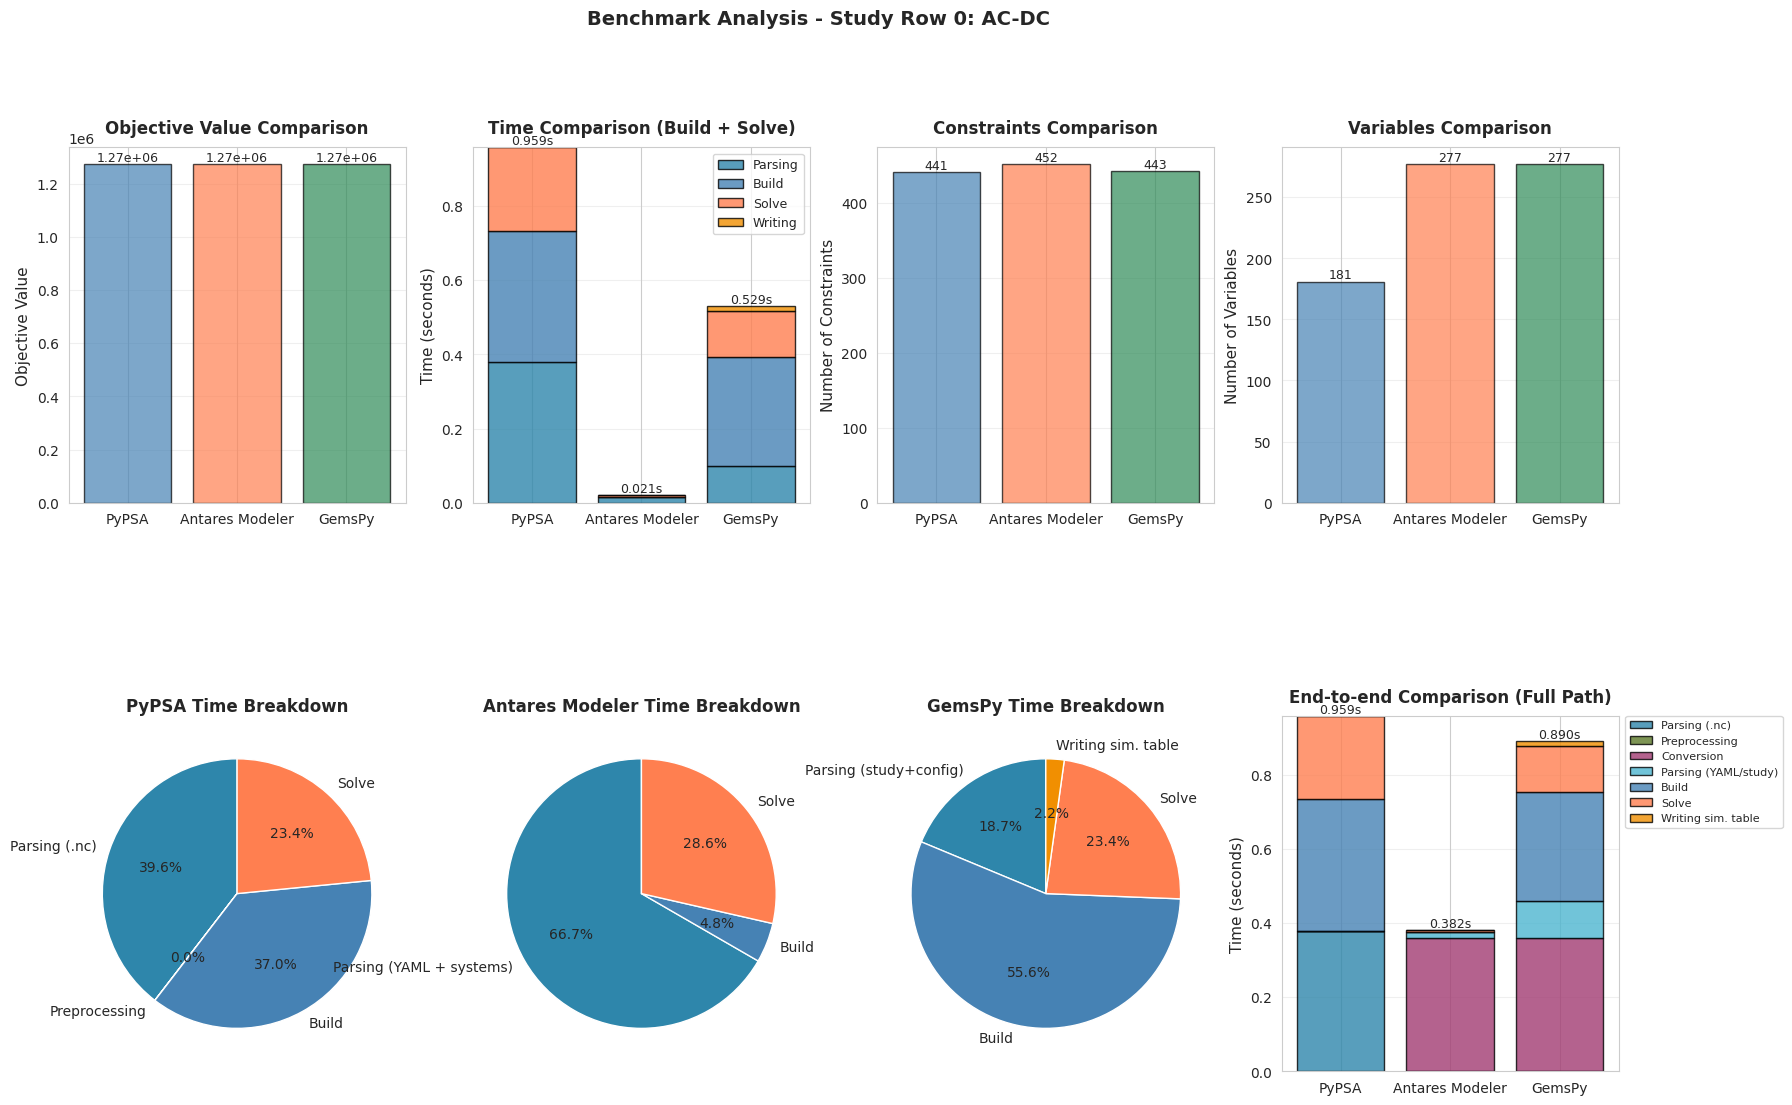

In [31]:
# Execute all studies
for i in range(1):
    analyze_benchmark_study(row_number=i)

## PyPSA vs Antares Xpansion (2-scenario stochastic)

Results from `tests/local_benchmark/benchmark_xpansion.py` (CSV: `tmp/benchmark_results/xpansion_benchmark_results.csv`).


In [32]:
# Verify Xpansion CSV and list available studies
xpansion_results_file = get_xpansion_results_path()
print(f"📁 Results file path: {xpansion_results_file}")
print(f"📁 File exists: {xpansion_results_file.exists()}")

if xpansion_results_file.exists():
    list_xpansion_benchmark_studies()
else:
    print(f"\n❌ Error: Results file not found at {xpansion_results_file}")
    print("Run: uv run pytest tests/local_benchmark/benchmark_xpansion.py -v -s")

📁 Results file path: /home/rtei-beg-see-dp/Gems-Development/PyPSA-to-GEMS-Converter/tmp/benchmark_results/xpansion_benchmark_results.csv
📁 File exists: True
Results file: /home/rtei-beg-see-dp/Gems-Development/PyPSA-to-GEMS-Converter/tmp/benchmark_results/xpansion_benchmark_results.csv
Total studies: 1

  Row 0: Tiny 2-scenario (synthetic)


### Xpansion usage

Call with a row number (0-indexed) to print the summary and plot PyPSA vs Xpansion:


XPANSION BENCHMARK - STUDY ROW 0

📊 STUDY INFORMATION:
  Study: Tiny 2-scenario (synthetic)
  Time steps: 168
  PyPSA version: 1.2.0
  Antares version: v10.1.0
  Antares Xpansion version: v1.9.0-rc1

⏱️  TIMING:
  Parsing (.nc / synthetic): 0.1614 s
  Preprocessing: 0.0000 s
  PyPSA build: 0.4963 s
  PyPSA solve: 0.6463 s
  PyPSA path total (parse+preproc+build+solve): 1.3041 s
  Conversion to GEMS study: 0.1007 s
  Problem generator: 0.0532 s
  Benders: 0.5687 s
  Xpansion path total (preproc+conversion+PG+Benders): 0.7226 s
  Xpansion reported run duration: 0.0056 s

📈 PROBLEM SIZE:
  PyPSA variables: 1013
  PyPSA constraints: 2694
  Antares Xpansion variables: 1180
  Variables ratio (PyPSA/Antares Xpansion): 0.8585
  Antares Xpansion constraints: 2024
  Constraints ratio (PyPSA/Antares Xpansion): 1.3310

🎯 OBJECTIVES:
  PyPSA total objective: 1183940.000000
  Antares Xpansion overall cost: 1183940.000000
  Difference (PyPSA - Antares Xpansion): 0.000000 (+0.0000%)
  PyPSA status: ok

/home/rtei-beg-see-dp/Gems-Development/PyPSA-to-GEMS-Converter/tests/utils.py:545: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



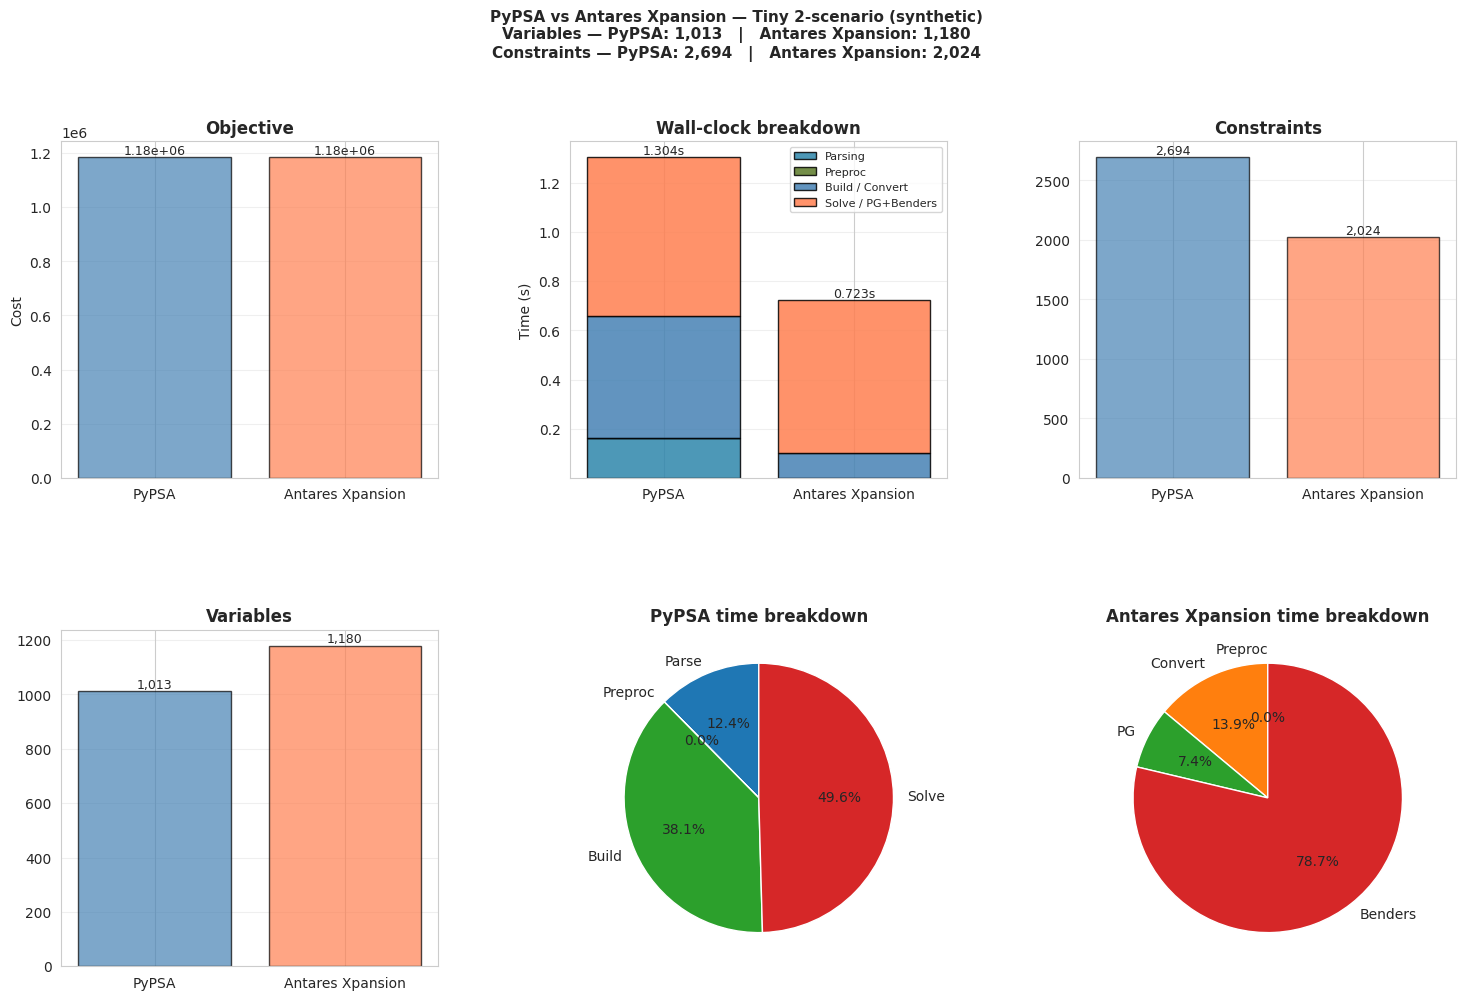

In [33]:
# Analyze one Xpansion benchmark row (text summary + plots)
XPANSION_ROW = 0  # index from list above
analyze_xpansion_benchmark_study(row_number=XPANSION_ROW)  # text summary, then plots

# Or run all rows:
# for i in range(len(df_x)):
#     analyze_xpansion_benchmark_study(row_number=i)